In [881]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.cm as cm

plt.style.use("fast")
plt.rcParams.update(
    {
        "font.size": 30,
        "font.family": "serif", 
        "text.usetex": False
    }
)
# use grid lines in plots
plt.rcParams["axes.grid"] = True
# dashed grid lines
plt.rcParams["grid.linestyle"] = "--"

# legend size
plt.rcParams["legend.fontsize"] = 30

In [882]:
DATASETS = [
    "ca-cit-HepPh",
    "linux",
    "link-dynamic-simplewiki",
    "web-stanford",
    "loc-gowalla",
    "ca-condmat",
    "ego-facebook",
    "email-enron",
    "ca-hepph"
]
DATASETS_LABELS = {
    "ca-cit-HepPh": "ca-cit-HepPh",
    "linux": "linux",
    "link-dynamic-simplewiki": "simplewiki",
    "web-stanford":"stanford",
    "loc-gowalla":"loc-gowalla",
    "ca-condmat":"ca-condmat",
    "ego-facebook":"facebook",
    "email-enron":"email-enron",
    "ca-hepph":"ca-hepph"
}

BASE_DIR = Path("../Esperimenti")
DATA_DIR = {dataset: BASE_DIR / dataset / "standard" for dataset in DATASETS}

In [883]:
DATA_DIR
k = 64
alpha = 0.3
phi = 0.8

In [884]:
def load_density(
    dataset: str, phi: float, alpha: float, k: int, baseline: bool = False
) -> np.ndarray:
    if baseline:
        path = DATA_DIR[dataset] / "density_dynamic_0.csv"
    else:
        path = (
            DATA_DIR[dataset]
            / f"density_credits_0_alpha{alpha:.6f}_phi{phi:.6f}_k{k}.csv"
        )

    data = pd.read_csv(path, header=None)
    density = data.iloc[:, :].mean(axis=1)
    return density.to_numpy()


def load_results(
    dataset: str, phi: float, alpha: float, k: int, baseline: bool = False
) -> np.ndarray:
    if baseline:
        path = DATA_DIR[dataset] / "results_dynamic_0.csv"
    else:
        path = (
            DATA_DIR[dataset]
            / f"results_credits_0_alpha{alpha:.6f}_phi{phi:.6f}_k{k}.csv"
        )

    data = pd.read_csv(path, header=None)
    results = data.iloc[:, :].mean(axis=1)
    return results.to_numpy()

def load_time(
    dataset: str, phi: float, alpha: float, k: int) -> np.ndarray:
    path_dynamic = DATA_DIR[dataset] / "times_dynamic_0.csv"
    path_credits = (
        DATA_DIR[dataset]
        / f"times_credits_0_alpha{alpha:.6f}_phi{phi:.6f}_k{k}.csv"
    )

    time_dynamic = pd.read_csv(path_dynamic, header=None).mean(axis=1)
    time_credits = pd.read_csv(path_credits, header=None).mean(axis=1)

    return time_dynamic[0]/time_credits[0]



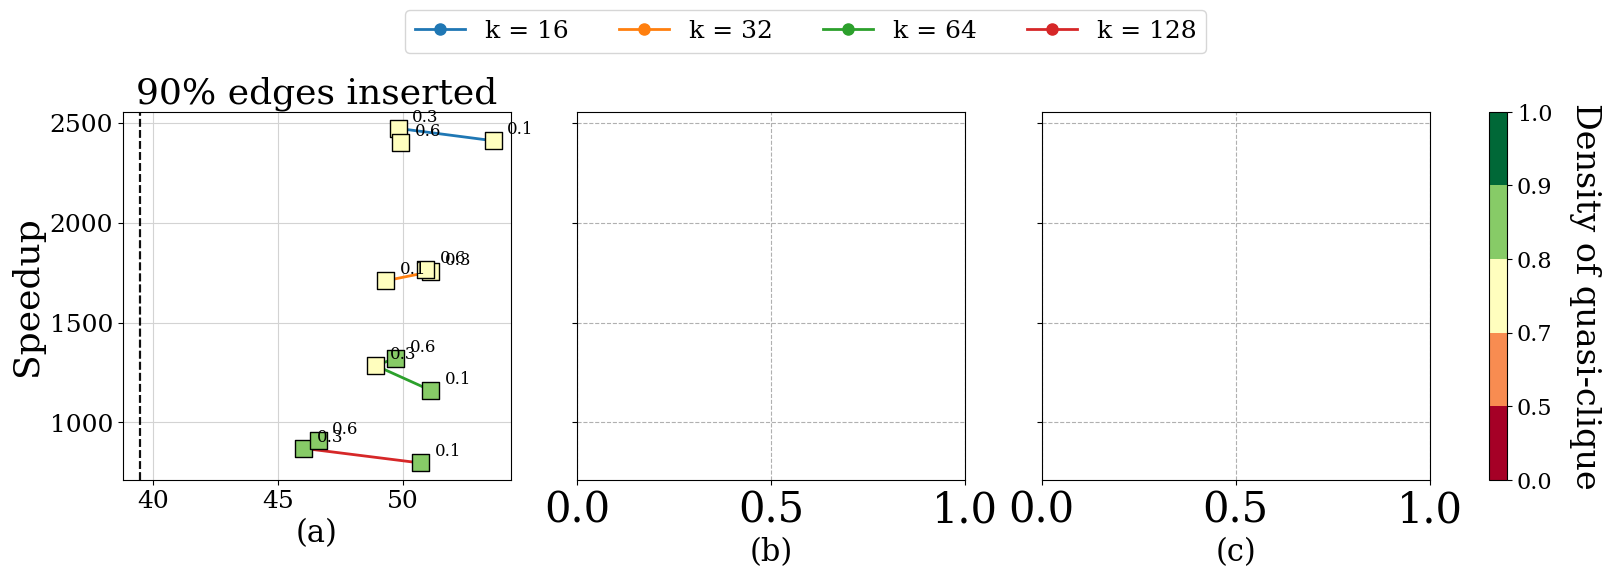

In [885]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- (Assicurati di avere le funzioni load_results, load_time, load_density definite) ---

save = False
dataset = "web-stanford"

fig, axs = plt.subplots(1, 3, figsize=(16, 5), layout="constrained",sharey=True)

cmap = plt.get_cmap('RdYlGn')
norm = mcolors.BoundaryNorm([0.0, 0.5, 0.7, 0.8, 0.9, 1.0], cmap.N)

p = 0.01
alpha_values = [ 0.1,0.3,0.6]
k_values = [16,32,64,128]
phi = 0.8

lines = []
labels = []

for i, perc in enumerate([0.9]):
    ax = axs[i]
    
    for k in k_values:
        size_list = []
        speedup_list = []
        density_list = []
        for alpha in alpha_values:
            size_values = load_results(dataset, phi, alpha, k, False)
            size = size_values[int((len(size_values)-1) * perc)]
            speedup = load_time(dataset, phi, alpha, k)
            density_values = load_density(dataset, phi, alpha, k)
            density = density_values[int((len(density_values)-1) * perc)]
            
            density_list.append(density) 
            size_list.append(size)
            speedup_list.append(speedup)
            
        size_baseline_values = load_results(dataset,phi,alpha,k,True)
        size_baseline = size_baseline_values[int((len(size_values)-1) * perc)]

        ##aggiungi qui una parte dove viene plottata una linea verticlae tratteggiata in corrispondenza di size_baseline
        ax.axvline(x=size_baseline, color='black', alpha=0.5, linestyle='--', linewidth=1.5, zorder=3)

        ax.scatter(
            size_list, speedup_list, s=150, marker="s", c=density_list,
            cmap=cmap, norm=norm, edgecolors="black", zorder=5
        )

        # --- AGGIUNTA DEL NUMERETTO ALPHA ---
        for x, y, a in zip(size_list, speedup_list, alpha_values):
            ax.annotate(
                f"{a}",               # Il testo da mostrare (il valore di alpha)
                (x, y),               # Le coordinate del punto
                textcoords="offset points", 
                xytext=(10, 5),       # Offset (x, y) in punti per non coprire il quadrato
                fontsize=12,          # Dimensione del testo
                zorder=6              # Assicura che il testo sia sopra i punti
            )
        # ------------------------------------

        line, = ax.plot(size_list, speedup_list, marker='o', markersize=8, linewidth=2)
        
        if i == 0:
            lines.append(line)
            labels.append(f'k = {k}')

    ax.set_title(fr'{int(perc*100)}% edges inserted', fontsize=26)
    ax.grid(True, linestyle='-', color='lightgray')
    
    ax.tick_params(axis='both', which='major', labelsize=18)

axs[0].set_ylabel('Speedup', fontsize=26)

axs[0].set_xlabel("(a)", fontsize=22)
axs[1].set_xlabel("(b)", fontsize=22)
axs[2].set_xlabel("(c)", fontsize=22)

fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=18)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=axs,
    location="right",
    pad=0.02,
    aspect=20
)
cbar.set_label("Density of quasi-clique", rotation=270, labelpad=35, fontsize=24)
cbar.ax.tick_params(labelsize=16)

if save:
    output_path = f"images/quality.pdf"
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
else:
    plt.show()